# Structural Break Analysis of German aFRR Markets

This notebook analyzes the structural break caused by Germany joining **PICASSO**.

- **Cut-off (market regime split):** `2022-06-22 22:00:00+00:00` (UTC)
- **Why this matters for battery simulation:** the mapping from system imbalance to local activation and balancing prices changes after coupling, so a single-stationary model can become biased.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CUT_OFF_UTC = pd.Timestamp('2022-06-22 22:00:00+00:00')


## 1) Data Load and Regime Setup

We load Netztransparenz data and construct one consistent market-regime flag.


In [2]:
# Primary source for structural-break analysis: cleaned merged dataset.
candidate_paths = [
    Path('data/processed/all_data_clean.parquet'),
    Path('../data/processed/all_data_clean.parquet'),
]

src_path = next((p for p in candidate_paths if p.exists()), None)
if src_path is None:
    raise FileNotFoundError(f'Could not find all_data_clean.parquet in: {candidate_paths}')

print(f'Using source: {src_path}')
df = pd.read_parquet(src_path)

if 'timestamp_utc' not in df.columns:
    raise KeyError("Missing required column 'timestamp_utc'")

df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)
df = df.sort_values('timestamp_utc').reset_index(drop=True)

df['market_regime'] = np.where(df['timestamp_utc'] < CUT_OFF_UTC, 'Pre-PICASSO', 'Post-PICASSO')

print(df[['timestamp_utc', 'market_regime']].head(2))
print(df[['timestamp_utc', 'market_regime']].tail(2))
print('Rows:', len(df))


Using source: ../data/processed/all_data_clean.parquet
              timestamp_utc market_regime
0 2020-11-30 23:00:00+00:00   Pre-PICASSO
1 2020-12-01 00:00:00+00:00   Pre-PICASSO
                  timestamp_utc market_regime
44566 2025-12-31 22:00:00+00:00  Post-PICASSO
44567 2025-12-31 23:00:00+00:00  Post-PICASSO
Rows: 44568


## 2) Data Availability: Platform Launch Effect

Before PICASSO/MARI go-live, optimization flow series are structurally unavailable. After go-live, they become populated and volatile.


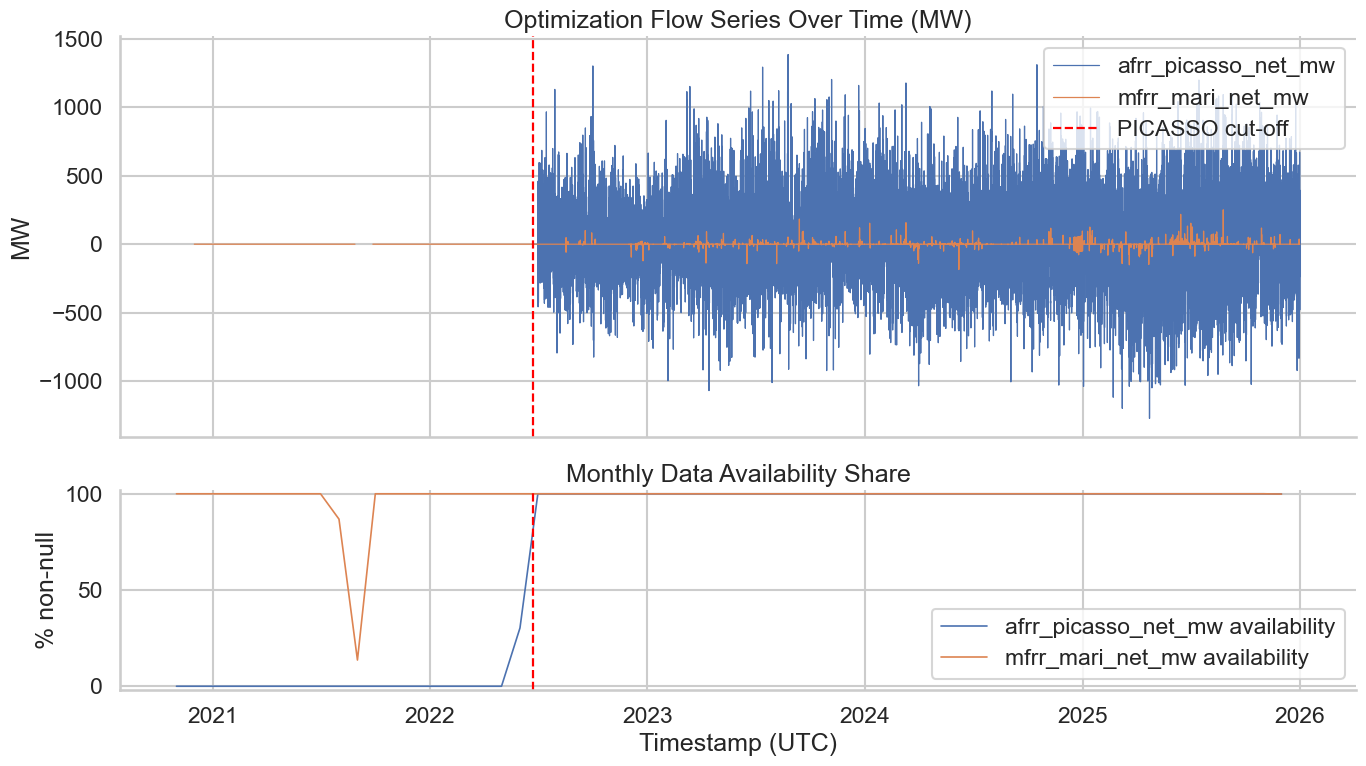

In [3]:
opt_cols = [c for c in ['afrr_picasso_net_mw', 'mfrr_mari_net_mw'] if c in df.columns]
if not opt_cols:
    raise KeyError("No optimization flow columns found. Expected one of: afrr_picasso_net_mw, mfrr_mari_net_mw")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

for col in opt_cols:
    axes[0].plot(df['timestamp_utc'], df[col], label=col, linewidth=0.9)

axes[0].axvline(CUT_OFF_UTC, color='red', linestyle='--', linewidth=1.6, label='PICASSO cut-off')
axes[0].set_title('Optimization Flow Series Over Time (MW)')
axes[0].set_ylabel('MW')
axes[0].legend(loc='upper right')

availability = (
    df.set_index('timestamp_utc')[opt_cols]
      .notna()
      .resample('MS')
      .mean()
      .multiply(100)
)

for col in opt_cols:
    axes[1].plot(availability.index, availability[col], label=f'{col} availability', linewidth=1.2)

axes[1].axvline(CUT_OFF_UTC, color='red', linestyle='--', linewidth=1.6)
axes[1].set_title('Monthly Data Availability Share')
axes[1].set_ylabel('% non-null')
axes[1].set_xlabel('Timestamp (UTC)')
axes[1].set_ylim(-2, 102)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


## 3) Decoupling of Local Activation from NRV Balance

Battery bidding logic often assumes that local imbalance (`NRV_balance`) maps strongly to local activation. Under cross-border coupling, this relationship can weaken.


In [4]:
def first_existing(cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

nrv_col = first_existing(['NRV_balance', 'nrv_balance'])
if nrv_col is None:
    raise KeyError('Missing NRV balance column')

# Build local aFRR activation magnitude from pos/neg components.
pos_col = first_existing(['afrr_activated_mw_pos'])
neg_col = first_existing(['afrr_activated_mw_neg'])
if pos_col is None or neg_col is None:
    raise KeyError('Missing aFRR activation columns afrr_activated_mw_pos/neg')

df['abs_nrv_mw'] = df[nrv_col].abs()
df['local_afrr_activation_mw'] = df[pos_col].fillna(0).abs() + df[neg_col].fillna(0).abs()

def regime_corr(frame):
    x = frame['abs_nrv_mw']
    y = frame['local_afrr_activation_mw']
    valid = x.notna() & y.notna()
    if valid.sum() < 3:
        return np.nan, int(valid.sum())
    return x[valid].corr(y[valid]), int(valid.sum())

pre = df[df['market_regime'] == 'Pre-PICASSO']
post = df[df['market_regime'] == 'Post-PICASSO']

corr_pre, n_pre = regime_corr(pre)
corr_post, n_post = regime_corr(post)

print('Pearson corr |abs(NRV)| vs local aFRR activation')
print(f'Pre-PICASSO : corr={corr_pre:.4f} (n={n_pre})')
print(f'Post-PICASSO: corr={corr_post:.4f} (n={n_post})')


Pearson corr |abs(NRV)| vs local aFRR activation
Pre-PICASSO : corr=0.4791 (n=13654)
Post-PICASSO: corr=0.5464 (n=30914)


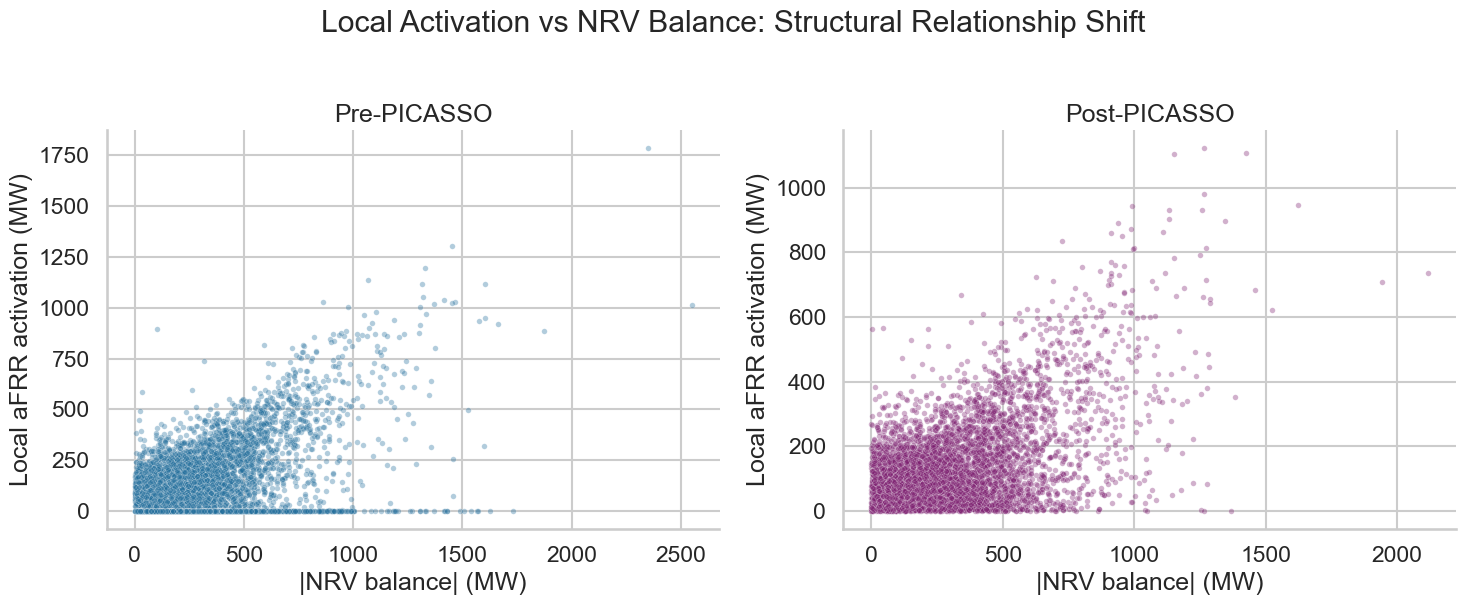

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False, sharey=False)

sns.scatterplot(
    data=pre.sample(min(len(pre), 6000), random_state=42),
    x='abs_nrv_mw', y='local_afrr_activation_mw',
    alpha=0.35, s=16, ax=axes[0], color='#226E9C'
)
axes[0].set_title('Pre-PICASSO')
axes[0].set_xlabel('|NRV balance| (MW)')
axes[0].set_ylabel('Local aFRR activation (MW)')

sns.scatterplot(
    data=post.sample(min(len(post), 6000), random_state=42),
    x='abs_nrv_mw', y='local_afrr_activation_mw',
    alpha=0.35, s=16, ax=axes[1], color='#7C1D6F'
)
axes[1].set_title('Post-PICASSO')
axes[1].set_xlabel('|NRV balance| (MW)')
axes[1].set_ylabel('Local aFRR activation (MW)')

plt.suptitle('Local Activation vs NRV Balance: Structural Relationship Shift', y=1.02)
plt.tight_layout()
plt.show()


## 4) Price Volatility Shift (Pay-as-Bid → Marginal Regime)

A regime change should also appear in the volatility of balancing-related price signals. We track rolling 7-day volatility and rolling 7-day max.


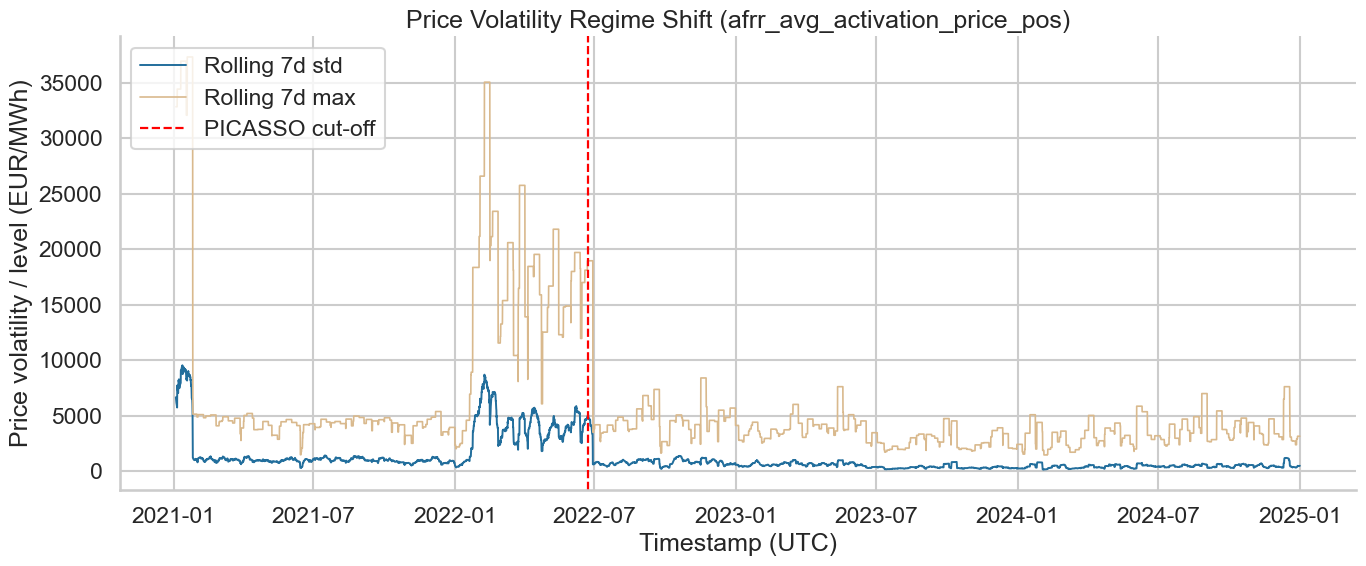

In [6]:
price_candidates = [
    'afrr_activation_marginal_price_pos',
    'afrr_avg_activation_price_pos',
    'reBAP_shortage_surplus',
]
price_col = next((c for c in price_candidates if c in df.columns), None)
if price_col is None:
    raise KeyError(f'No price column found. Tried: {price_candidates}')

p = df[['timestamp_utc', 'market_regime', price_col]].dropna().copy()
p = p[(p['timestamp_utc'] >= '2021-01-01') & (p['timestamp_utc'] < '2025-01-01')]
p = p.sort_values('timestamp_utc').set_index('timestamp_utc')

# Hourly data => 7 days == 168 observations.
p['rolling_std_7d'] = p[price_col].rolling(window=24*7, min_periods=24*3).std()
p['rolling_max_7d'] = p[price_col].rolling(window=24*7, min_periods=24*3).max()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(p.index, p['rolling_std_7d'], color='#226E9C', linewidth=1.4, label='Rolling 7d std')
ax.plot(p.index, p['rolling_max_7d'], color='#d9b98d', linewidth=1.2, label='Rolling 7d max')
ax.axvline(CUT_OFF_UTC, color='red', linestyle='--', linewidth=1.6, label='PICASSO cut-off')
ax.set_title(f'Price Volatility Regime Shift ({price_col})')
ax.set_ylabel('Price volatility / level (EUR/MWh)')
ax.set_xlabel('Timestamp (UTC)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## 5) Interpretation for Battery Simulation

- **Feature availability changed structurally:** optimization-flow features are platform-dependent and effectively absent before go-live.
- **Signal-to-activation link changed:** the pre-2022 mapping from local imbalance to local aFRR activation weakens after coupling.
- **Volatility regime shifted:** post-2022 price dynamics include stronger spikes/regime behavior.

For production modeling, use explicit regime features (or separate models) and avoid assuming stationarity across this break.
